# Testing PICASO and Photochem Updates: Stores/Passes Cases that Ran into Exceptions

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
import copy
import pandas as pd
from scipy import optimize
from matplotlib import pyplot as plt
import pickle
from itertools import cycle
import matplotlib.colors as mcolors
import astropy.units as u
import astropy.constants as const

from photochem.utils import stars
import PICASO_Climate_grid_121625 as picaso_grid
import Photochem_grid_121625 as photochem_grid
import Reflected_Spectra_grid_13026 as Reflected_Spectra
from picaso.photochem import EquilibriumChemistry
import GraphsKey

import os
from pathlib import Path

current_directory = Path.cwd()
references_directory_path = "Installation&Setup_Instructions/picasofiles/reference"
PYSYN_directory_path = "Installation&Setup_Instructions/picasofiles/grp/redcat/trds"
print(os.path.join(current_directory, references_directory_path))
print(os.path.join(current_directory, PYSYN_directory_path))

os.environ['picaso_refdata']= os.path.join(current_directory, references_directory_path)
os.environ['PYSYN_CDBS']= os.path.join(current_directory, PYSYN_directory_path)


import picaso.justdoit as jdi
import picaso.justplotit as jpi

/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation&Setup_Instructions/picasofiles/reference
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation&Setup_Instructions/picasofiles/grp/redcat/trds
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation&Setup_Instructions/picasofiles/reference
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation&Setup_Instructions/picasofiles/grp/redcat/trds
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation&Setup_Instructions/picasofiles/reference/opacities/opacities_photochem_0.1_250.0_R15000.db
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation&Setup_Instructions/picasofiles/reference
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation&Setup_Instructions/picasofiles/grp/redcat/trds


### Load/Solve for PICASO file

Keys in the HDF5 file: ['completed', 'inputs', 'results']
[array([1.6e+00, 3.0e+00, 1.0e+02, 9.0e+00, 1.0e-02]), array([  1.6,   3. , 100. ,   9. ,   1. ]), array([1.6e+00, 3.0e+00, 1.0e+02, 1.0e+01, 1.0e-02]), array([  1.6,   3. , 100. ,  10. ,   1. ])]
[array([[[[[b'ZeroDivisionError: division by zero'],
          [b'']],

         [[b'ZeroDivisionError: division by zero'],
          [b'']]]]], dtype='|S35')]
[137.95532544218923, 137.86677962991067, 137.83877468563804, 137.77115233996506, 137.2971925376003, 136.13990316331913, 135.79320421982288, 137.3807751366978, 50.63263782547145, 64.99091366727706, 67.89416494779314, 72.52420871830475, 73.29900582456654, 75.35022817613343, 75.44399046556276, 75.44320125962899, 74.66251069620424, 74.9583415017492, 74.71719247167867, 71.2013381300222, 71.91896749033353, 77.6951446572901, 80.607235816427, 80.88675935680342, 86.01145819540575, 87.05031930945728, 87.55894488241974, 87.82278288882505, 87.95344067854347, 88.14840385933351, 88.3789831035

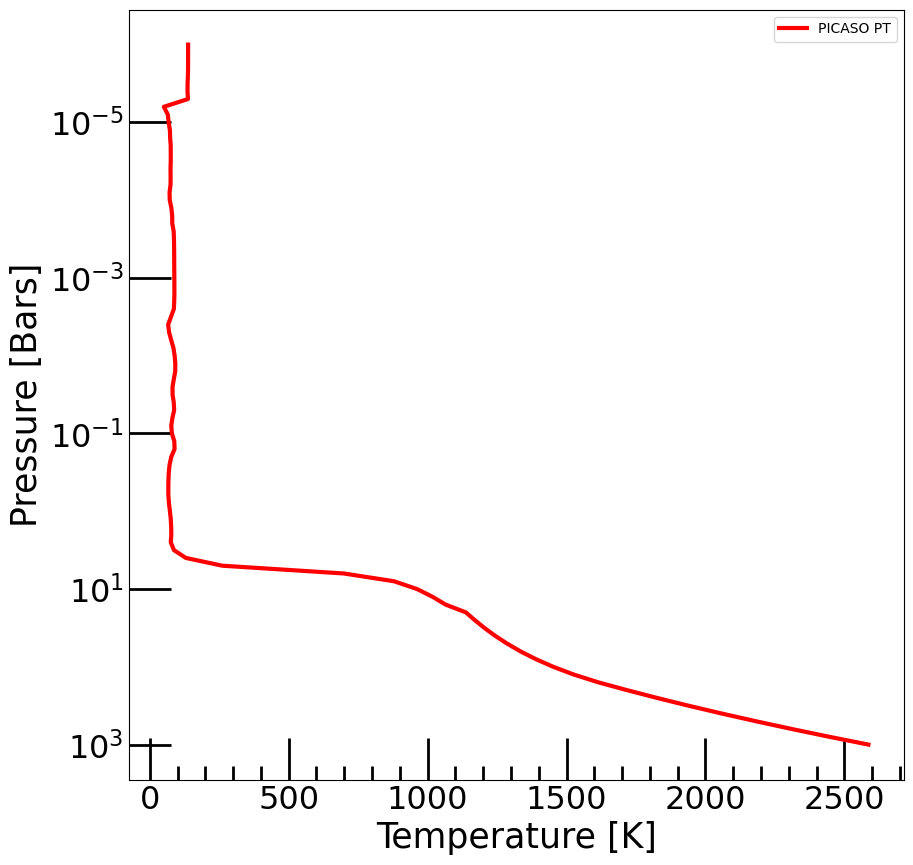

In [9]:
file_path = "results/PICASO_climate_updatop_paramext_SMALLtest_v2.h5"
with h5py.File(file_path, 'r') as f:
    # 1. List all keys/datasets in the file
    print("Keys in the HDF5 file:", list(f.keys()))
    print(list(f['inputs']))
    print(list(f['results']['error']))
    print(list(f['results']['temperature'][0][0][0][0][1]))
    print(list(f['inputs'][0])[0])

    # Plot the PT Profile from PICASO
    
    plt.figure(figsize=(10,10))
    plt.ylabel("Pressure [Bars]", fontsize=25)
    plt.xlabel('Temperature [K]', fontsize=25)
    plt.gca().invert_yaxis()
    #plt.ylim(500,1e-4)
    #plt.xlim(250,1750)
    
    plt.semilogy(list(f['results']['temperature'][0][0][0][0][1]),list(f['results']['pressure'][0][0][0][0][1]),color="r",linewidth=3, label='PICASO PT')    
    plt.minorticks_on()
    plt.tick_params(axis='both',which='major',length =30, width=2,direction='in',labelsize=23)
    plt.tick_params(axis='both',which='minor',length =10, width=2,direction='in',labelsize=23)

    plt.legend()

    #Tef = stars.equilibrium_temperature(total_flux*1361, 0)
    #plt.title(f"Teff = {Tef} K, log(g)=4.4")

    plt.show()

In [10]:
# Calculate what inputs didn't complete

import itertools

def generate_combinations_with_ranges(input_lists):
  """
  Generates all combinations from a list of inputs, which can be
  lists of values or range objects.

  Args:
    input_lists: A list of iterables (lists or ranges).

  Returns:
    A list of tuples, where each tuple is a combination.
  """
  # itertools.product takes each input list as an argument
  # The '*' unpacks the input_lists into separate arguments
  all_combinations = list(itertools.product(*input_lists))
  return all_combinations

# --- Example Usage ---

# Define your inputs, including standard lists and ranges
# Format for a range should be a range() object: range(start, stop, step)

rad_plan_earth_units = np.array([1.6]) # in units of xEarth radii
log10_planet_metallicity = np.array([3]) # in units of solar metallicity
tint_K = np.array([100]) # in Kelvin
semi_major_AU = np.array([9, 10]) # in AU 
ctoO_solar = np.array([0.01, 1]) # in units of solar C/O

inputs = [
    rad_plan_earth_units,          
    log10_planet_metallicity,      
    tint_K,
    semi_major_AU,
    ctoO_solar
]

# Generate the combinations
picaso_combinations_list = generate_combinations_with_ranges(inputs)

# Print the results
print(f"Total combinations: {len(picaso_combinations_list)}\n")
print(np.array(picaso_combinations_list))

Total combinations: 4

[[1.6e+00 3.0e+00 1.0e+02 9.0e+00 1.0e-02]
 [1.6e+00 3.0e+00 1.0e+02 9.0e+00 1.0e+00]
 [1.6e+00 3.0e+00 1.0e+02 1.0e+01 1.0e-02]
 [1.6e+00 3.0e+00 1.0e+02 1.0e+01 1.0e+00]]


[array([1.6e+00, 3.0e+00, 1.0e+02, 9.0e+00, 1.0e-02]), array([  1.6,   3. , 100. ,   9. ,   1. ]), array([1.6e+00, 3.0e+00, 1.0e+02, 1.0e+01, 1.0e-02]), array([  1.6,   3. , 100. ,  10. ,   1. ])]
Inputs of failed PICASO calcultions: []
This is an example of inputs: [1.6e+00 3.0e+00 1.0e+02 9.0e+00 1.0e-02]
[1.6e+00 3.0e+00 1.0e+02 9.0e+00 1.0e-02]
Make sure your inputs are within the following ranges, rad_plan: 1.6 - 1.6 xEarth Radii, planet metallicity: 3.0 - 3.0 xsolar, tint: 100 - 100 K, semi_major: 9 - 10 AU, ctoO: 0.01 - 1.0
This is the input list: [1.6e+00 3.0e+00 1.0e+02 9.0e+00 1.0e-02]
Was able to successfully find your input parameters in the PICASO TP profile grid!
All inputs chosen were directly on the grid!
Does not include Photochemistry extension of PT profile


ValueError: math domain error

<Figure size 1000x1000 with 1 Axes>

This is an example of inputs: [  1.6   3.  100.    9.    1. ]
[  1.6   3.  100.    9.    1. ]
Make sure your inputs are within the following ranges, rad_plan: 1.6 - 1.6 xEarth Radii, planet metallicity: 3.0 - 3.0 xsolar, tint: 100 - 100 K, semi_major: 9 - 10 AU, ctoO: 0.01 - 1.0
This is the input list: [  1.6   3.  100.    9.    1. ]
Was able to successfully find your input parameters in the PICASO TP profile grid!
All inputs chosen were directly on the grid!
Does not include Photochemistry extension of PT profile


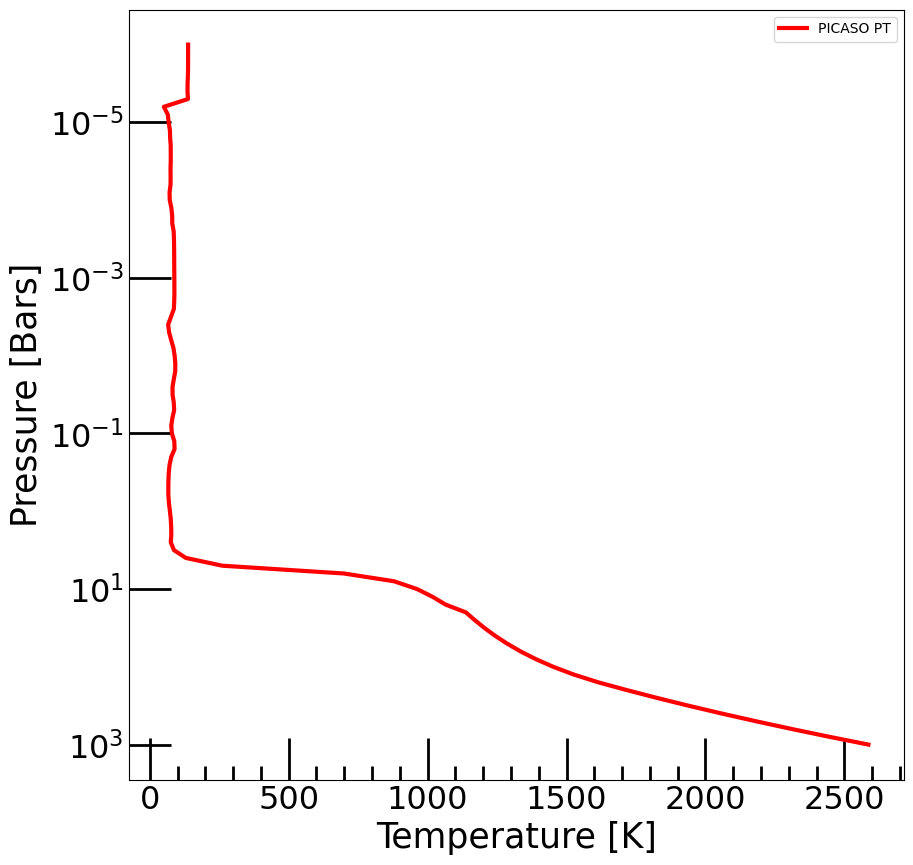

This is an example of inputs: [1.6e+00 3.0e+00 1.0e+02 1.0e+01 1.0e-02]
[1.6e+00 3.0e+00 1.0e+02 1.0e+01 1.0e-02]
Make sure your inputs are within the following ranges, rad_plan: 1.6 - 1.6 xEarth Radii, planet metallicity: 3.0 - 3.0 xsolar, tint: 100 - 100 K, semi_major: 9 - 10 AU, ctoO: 0.01 - 1.0
This is the input list: [1.6e+00 3.0e+00 1.0e+02 1.0e+01 1.0e-02]
Was able to successfully find your input parameters in the PICASO TP profile grid!
All inputs chosen were directly on the grid!
Does not include Photochemistry extension of PT profile


ValueError: math domain error

<Figure size 1000x1000 with 1 Axes>

This is an example of inputs: [  1.6   3.  100.   10.    1. ]
[  1.6   3.  100.   10.    1. ]
Make sure your inputs are within the following ranges, rad_plan: 1.6 - 1.6 xEarth Radii, planet metallicity: 3.0 - 3.0 xsolar, tint: 100 - 100 K, semi_major: 9 - 10 AU, ctoO: 0.01 - 1.0
This is the input list: [  1.6   3.  100.   10.    1. ]
Was able to successfully find your input parameters in the PICASO TP profile grid!
All inputs chosen were directly on the grid!
Does not include Photochemistry extension of PT profile


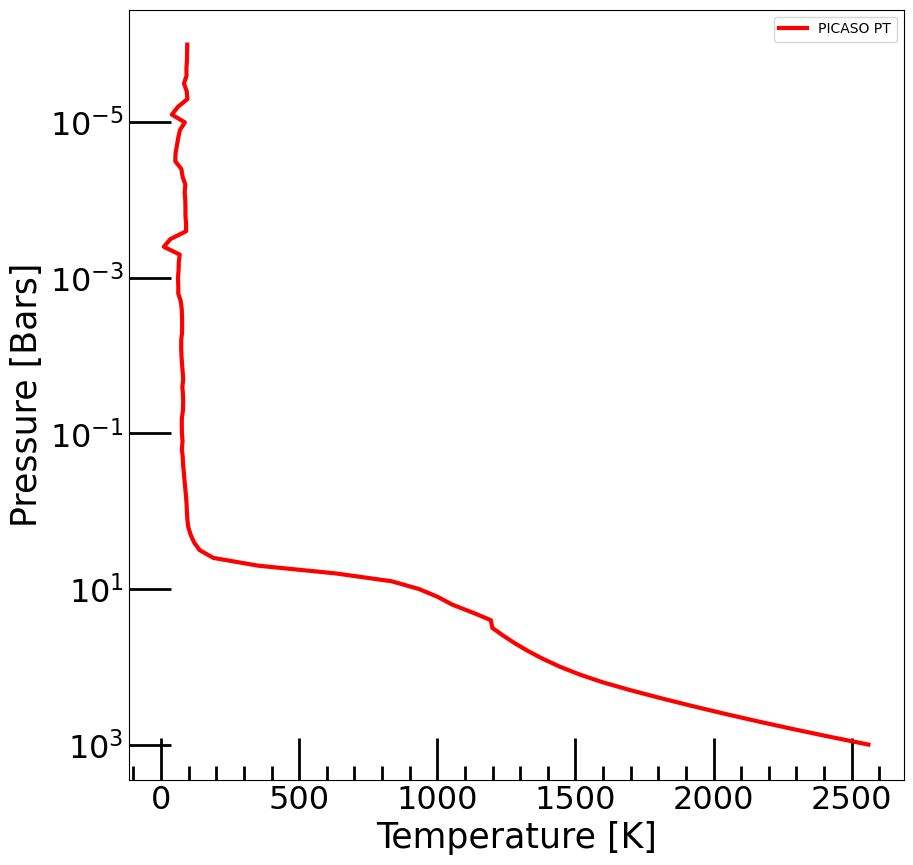

In [11]:
filename_picaso ='results/PICASO_climate_updatop_paramext_SMALLtest_v2.h5'
indices_dnf = []

with h5py.File(filename_picaso, 'r') as f:
    picaso_data = f
    #print(len(list(photochem_data['inputs'])))
    print(list(picaso_data['inputs']))
    picaso_completed_list = np.array(list(picaso_data['completed']))

    try:
        indicies_true = np.where(picaso_completed_list)[0]
    except:
        print(f"No results were True, no calculations were completed")

    # Find matching indices
    # Reshape arr2 for broadcasting
    # This ensures a comparison is made for each row in arr1 against all rows in arr2
    arr2 = np.array(list(picaso_data['inputs']))
    arr1 = np.array(picaso_combinations_list)

    # 1. Compare all rows of arr1 to all rows of arr2
    #    Result is a 3D boolean array where:
    #    - the first dimension matches arr1 rows
    #    - the second dimension matches arr2 rows
    #    - the third dimension matches columns
    #    Shape will be (arr1.shape[0], arr2.shape[0], arr1.shape[1]) -> (4, 2, 3)
    comparison = arr1[:, None, :] == arr2[None, :, :]
    
    # 2. Check if all elements in a row comparison are True
    #    Use np.all() along the last axis (axis=2)
    #    Result is a 2D boolean array (4, 2)
    rows_match = np.all(comparison, axis=2)
    
    # 3. Check if any row in arr2 matches the corresponding row in arr1
    #    Use np.any() along the second axis (axis=1)
    #    Result is a 1D boolean array (4,) indicating which rows in arr1 had a match in arr2
    any_match = np.any(rows_match, axis=1)
    
    # 4. Get the indices of the True values in the boolean mask
    #    Use np.where() to return the indices
    matching_indices = np.where(any_match)[0]
    non_matching_indices = np.where(~any_match)[0]

    # 5. Determine what input values were not calculated
    for index in non_matching_indices:
        indices_dnf.append(picaso_combinations_list[index])
    
    #print(f"Indices of matching rows in arr1: {matching_indices}")
    #print(f"Indices of non-matching rows in arr1: {non_matching_indices}")
    print(f"Inputs of failed PICASO calcultions: {indices_dnf}")

    for index in indicies_true:
        inputs = picaso_data['inputs'][index]
        print(f"This is an example of inputs: {inputs}")
        print(inputs)
        GraphsKey.plot_PT(rad_plan=inputs[0], planet_metal=inputs[1], tint=inputs[2], semi_major=inputs[3], ctoO=inputs[4], kzz=None, calc_PT=True, calc_PhotCh=False, PT_filepath=filename_picaso)